In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pickle as pk
import sys
import sailfish
import matplotlib.colors as mcolors
from matplotlib.patches import Circle
import cmocean, cmasher
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MultipleLocator
from scipy.signal import lombscargle

from sailfish.physics.cooling import ShakuraSunyaevDisk, cgs, PlanckSpectrum
from sailfish.physics.kepler import OrbitalState, PointMass
from Diagnostics import DavidTimeseries, eccentric_anomaly
transparent_black = mcolors.LinearSegmentedColormap.from_list("transparent_black", [(0, (1, 1, 1, 0)), (1, (0, 0, 0, 1))])

text_width   = 5.0 #6.8
column_width = 2.4 #3.3
def configure_matplotlib():
    plt.rc('xtick' , labelsize=8)
    plt.rc('ytick' , labelsize=8)
    plt.rc('axes'  , labelsize=8)
    plt.rc('legend', fontsize=8)
    plt.rc('font', family='DejaVu Sans', size=8)
    plt.rc('text', usetex=True)
    plt.rcParams.update({
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 5,
        "ytick.major.size": 5,
        "xtick.major.width": 2,
        "ytick.major.width": 2,
        "xtick.color": "black",
        "ytick.color": "black",
    })
    plt.rcParams.update({
        "axes.linewidth": 2,  # default is 0.8
    })
configure_matplotlib()

## Disk Remapping Parameters

In [2]:
Mach10_Remapping = ShakuraSunyaevDisk(
    central_mass_msun = 8e6, 
    length_scale_pc   = 9.7e-4,
    mach_number_a     = 10,
    alpha             = 0.1,
    gamma             = 5./3.,
    target_accretion_rate=0.1,
).Mdrop

Mach20_Remapping = ShakuraSunyaevDisk(
    central_mass_msun = 8e6, 
    length_scale_pc   = 9.7e-4,
    mach_number_a     = 20,
    alpha             = 0.1,
    gamma             = 5./3.,
    target_accretion_rate=0.1,
).Mdrop

Mach40_Remapping = ShakuraSunyaevDisk(
    central_mass_msun = 8e6, 
    length_scale_pc   = 9.7e-4,
    mach_number_a     = 40,
    alpha             = 0.1,
    gamma             = 5./3.,
    target_accretion_rate=0.1,
).Mdrop

Mach80_Remapping = ShakuraSunyaevDisk(
    central_mass_msun = 8e6, 
    length_scale_pc   = 9.7e-4,
    mach_number_a     = 80,
    alpha             = 0.1,
    gamma             = 5./3.,
    target_accretion_rate=0.1,
).Mdrop

Mach160_Remapping = ShakuraSunyaevDisk(
    central_mass_msun = 8e6, 
    length_scale_pc   = 9.7e-4,
    mach_number_a     = 160,
    alpha             = 0.1,
    gamma             = 5./3.,
    target_accretion_rate=0.1,
).Mdrop

print('=== Rescaling values from simulated disk to implied Eddington ratio of 0.1 ===')
print('-----------------+-----------------------------------------------------------+')
print('                 | Mach 10   |  Mach 20  |  Mach 40  |  Mach 80  |  Mach 160 |')
print('-----------------+-----------------------------------------------------------+')
print(f"Mdrop values     | {Mach10_Remapping:.3e} | {Mach20_Remapping:.3e} | {Mach40_Remapping:.3e} | {Mach80_Remapping:.3e} | {Mach160_Remapping:.3e} |")
print(f"A values         | {1/Mach10_Remapping:.3e} | {1/Mach20_Remapping:.3e} | {1/Mach40_Remapping:.3e} | {1/Mach80_Remapping:.3e} | {1/Mach160_Remapping:.3e} |")

=== Rescaling values from simulated disk to implied Eddington ratio of 0.1 ===
-----------------+-----------------------------------------------------------+
                 | Mach 10   |  Mach 20  |  Mach 40  |  Mach 80  |  Mach 160 |
-----------------+-----------------------------------------------------------+
Mdrop values     | 6.456e-08 | 2.066e-06 | 6.611e-05 | 2.116e-03 | 6.770e-02 |
A values         | 1.549e+07 | 4.840e+05 | 1.513e+04 | 4.727e+02 | 1.477e+01 |


In [3]:
def ViscousTime(r, Mach, alpha):
    return (5/24/np.pi) * (r**1.6) * Mach**2 / alpha

print('Viscous time                    : ',1 / ViscousTime(r=0.05, Mach=20, alpha=0.1))

def EddingtonFraction(Mach, M, r, gamma=5/3, alpha=0.1, eta=0.1):
    kappa_es = 0.4 # in cgs
    rg       = cgs['G'] * M / cgs['c'] / cgs['c']
    c1       = np.sqrt(4 * cgs['sigmab'] * kappa_es * cgs['c']**2 * cgs['mp']**4 / (cgs['kb']**4) / 3)
    c2       = (0.1**0.5) * (5/3)**(-2) * (2530*rg)**(-0.25) * (cgs['G'] * 8e6*cgs['msun'])**0.75 * 1e-5 * 0.1
    print('Eddington Fraction (Coefficient): ', c1 * c2/np.sqrt(2))
    return c1 * c2 * (alpha/0.1)**0.5 * (gamma/(5/3))**(-2) * (r/(2530))**(-0.25) * (M/(8e6*cgs['msun']))**0.75 * (Mach/10)**(-5) * (eta/0.1) / np.sqrt(2)

print('Eddington Fraction (Analytic)   : ', EddingtonFraction(Mach=40, M=8e6*cgs['msun'], r=2530, gamma=5/3, alpha=0.1, eta=0.1))
print('Eddington Fraction (Class)      : ', ShakuraSunyaevDisk(
    central_mass_msun = 8e6, 
    length_scale_pc   = 9.7e-4,
    mach_number_a     = 120,
    alpha             = 0.1,
    gamma             = 5./3.,
    target_accretion_rate=0.1,
)._eddington_fraction)

Viscous time                    :  0.4549661771845357
Eddington Fraction (Coefficient):  1549425.459811666
Eddington Fraction (Analytic)   :  1513.1108005973301
Eddington Fraction (Class)      :  6.224559896306781


## Density Map Colour Schemes

In [4]:
def load_checkpoint(filename, require_solver=None):
    with open(filename, "rb") as f:
        chkpt = pk.load(file=f)
    return chkpt


data        = {}
dir         = '/mnt/beegfs/haimagrp/david_oneill/sailfish/Retrograde/Sweeps/'
Checkpoints = ['Mach10/n5000/chkpt.0100.pk' , 'Mach10/n5000/chkpt.0267.pk' , 'Mach10/n5000/chkpt.0434.pk',
               'Mach20/n20000/chkpt.0400.pk', 'Mach20/n20000/chkpt.1150.pk', 'Mach20/n20000/chkpt.1900.pk',
               'Mach10/n5000/chkpt.0400.pk' , 'Mach10/n5000/chkpt.0240.pk' , 'Mach10/n5000/chkpt.0240.pk']
Names       = ['M10_e00'                , 'M10_e03'                , 'M10_e06',
               'M20_e00'                , 'M20_e03'                , 'M20_e06',
               'M40_e00'                , 'M40_e00'                , 'M40_e00']


for index in range(0, len(Checkpoints)):
    data[Names[index]] = load_checkpoint(dir + Checkpoints[index])


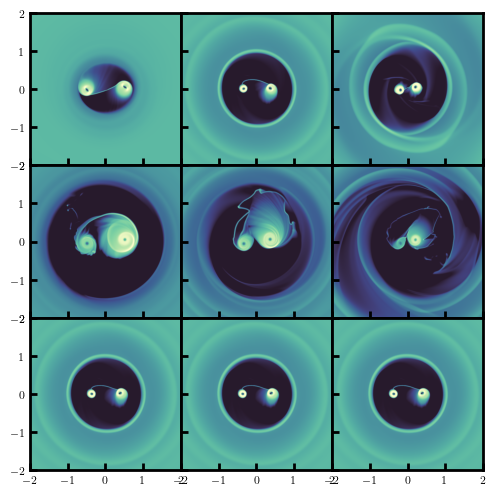

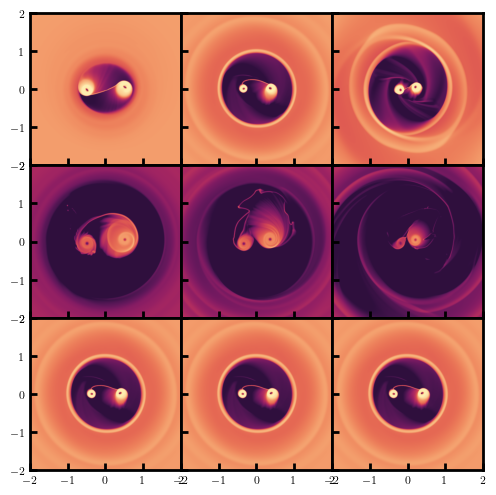

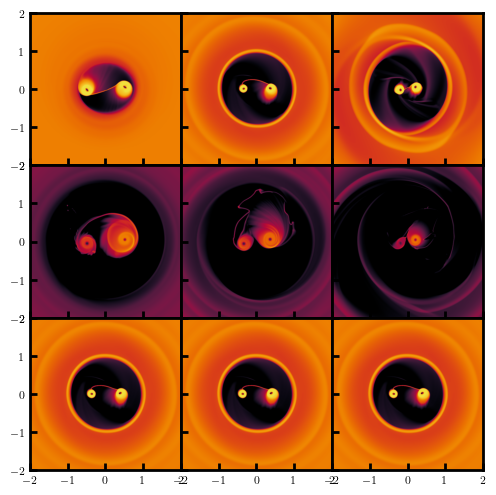

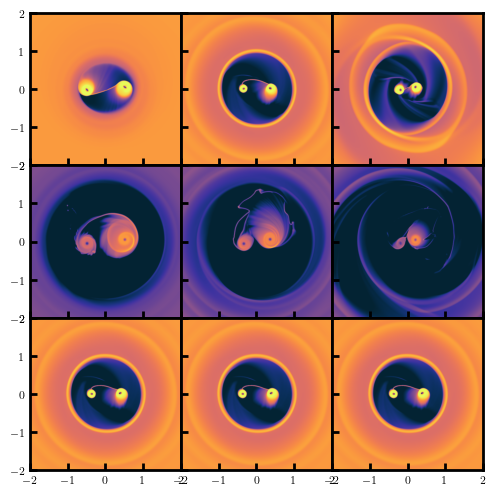

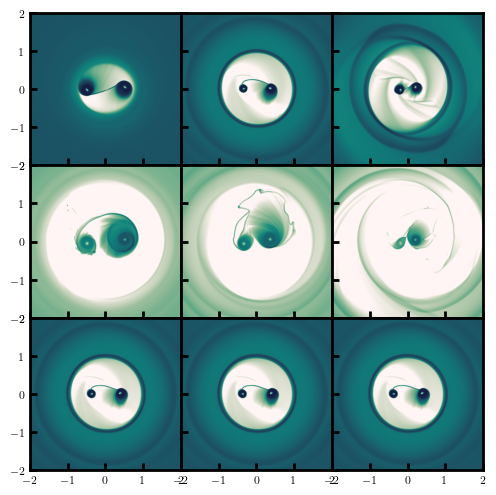

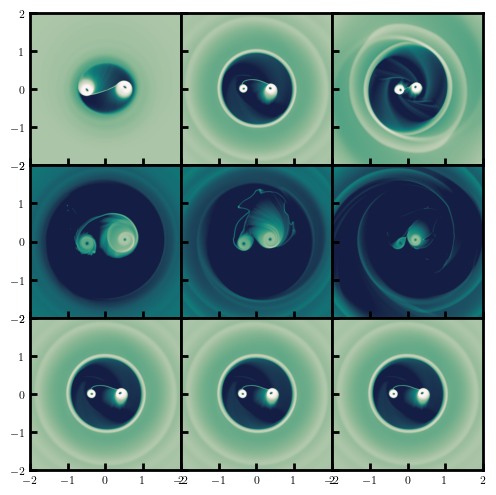

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(text_width, text_width), dpi=100,
                         sharex=True, sharey=True,
                         height_ratios=[0.33, 0.33, 0.33],
                         gridspec_kw={'hspace': 0.0, 'wspace': 0.0})
axes_flat = axes.flatten()


for index in range(0, len(Checkpoints)):
    ax     = axes_flat[index]
    chkpt  = data[Names[index]]
    Mdrop  = chkpt['SS73'].Mdrop
    Sigma  = chkpt["solution"][:, :, 0].T  * Mdrop**(3./5.)
    mesh   = chkpt["mesh"]
    extent = mesh.x0, mesh.x1, mesh.y0, mesh.y1
    cm     = ax.imshow(
                    np.log10(Sigma),
                    origin="lower",
                    vmin=-7,
                    vmax=-4,
                    cmap=cmocean.cm.deep_r,
                    extent=extent
                    )
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    ax.set_aspect('auto')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(3, 3, figsize=(text_width, text_width), dpi=100,
                         sharex=True, sharey=True,
                         height_ratios=[0.33, 0.33, 0.33],
                         gridspec_kw={'hspace': 0.0, 'wspace': 0.0})
axes_flat = axes.flatten()


for index in range(9):
    ax     = axes_flat[index]
    chkpt  = data[Names[index]]
    Sigma  = chkpt["solution"][:, :, 0].T 
    mesh   = chkpt["mesh"]
    extent = mesh.x0, mesh.x1, mesh.y0, mesh.y1
    cm     = ax.imshow(
                    np.log10(Sigma),
                    origin="lower",
                    vmin=-3,
                    vmax= 0,
                    cmap=cmocean.cm.matter_r,
                    extent=extent
                    )
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    ax.set_aspect('auto')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(text_width, text_width), dpi=100,
                         sharex=True, sharey=True,
                         height_ratios=[0.33, 0.33, 0.33],
                         gridspec_kw={'hspace': 0.0, 'wspace': 0.0})
axes_flat = axes.flatten()


for index in range(9):
    ax     = axes_flat[index]
    chkpt  = data[Names[index]]
    Sigma  = chkpt["solution"][:, :, 0].T 
    mesh   = chkpt["mesh"]
    extent = mesh.x0, mesh.x1, mesh.y0, mesh.y1
    cm     = ax.imshow(
                    np.log10(Sigma),
                    origin="lower",
                    vmin=-3,
                    vmax= 0,
                    cmap=cmasher.ember,
                    extent=extent
                    )
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    ax.set_aspect('auto')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(text_width, text_width), dpi=100,
                         sharex=True, sharey=True,
                         height_ratios=[0.33, 0.33, 0.33],
                         gridspec_kw={'hspace': 0.0, 'wspace': 0.0})
axes_flat = axes.flatten()


for index in range(9):
    ax     = axes_flat[index]
    chkpt  = data[Names[index]]
    Sigma  = chkpt["solution"][:, :, 0].T 
    mesh   = chkpt["mesh"]
    extent = mesh.x0, mesh.x1, mesh.y0, mesh.y1
    cm     = ax.imshow(
                    np.log10(Sigma),
                    origin="lower",
                    vmin=-3,
                    vmax= 0,
                    cmap=cmocean.cm.thermal,
                    extent=extent
                    )
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    ax.set_aspect('auto')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(3, 3, figsize=(text_width, text_width), dpi=100,
                         sharex=True, sharey=True,
                         height_ratios=[0.33, 0.33, 0.33],
                         gridspec_kw={'hspace': 0.0, 'wspace': 0.0})
axes_flat = axes.flatten()


for index in range(9):
    ax     = axes_flat[index]
    chkpt  = data[Names[index]]
    Sigma  = chkpt["solution"][:, :, 0].T 
    mesh   = chkpt["mesh"]
    extent = mesh.x0, mesh.x1, mesh.y0, mesh.y1
    cm     = ax.imshow(
                    np.log10(Sigma),
                    origin="lower",
                    vmin=-3,
                    vmax= 0,
                    cmap=cmocean.cm.tempo,
                    extent=extent
                    )
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    ax.set_aspect('auto')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(text_width, text_width), dpi=100,
                         sharex=True, sharey=True,
                         height_ratios=[0.33, 0.33, 0.33],
                         gridspec_kw={'hspace': 0.0, 'wspace': 0.0})
axes_flat = axes.flatten()


for index in range(9):
    ax     = axes_flat[index]
    chkpt  = data[Names[index]]
    Sigma  = chkpt["solution"][:, :, 0].T 
    mesh   = chkpt["mesh"]
    extent = mesh.x0, mesh.x1, mesh.y0, mesh.y1
    cm     = ax.imshow(
                    np.log10(Sigma),
                    origin="lower",
                    vmin=-3,
                    vmax= 0,
                    cmap=cmocean.cm.tempo_r,
                    extent=extent
                    )
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    ax.set_aspect('auto')

plt.tight_layout()
plt.show()


/tmp/ipykernel_3961389/1611715166.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


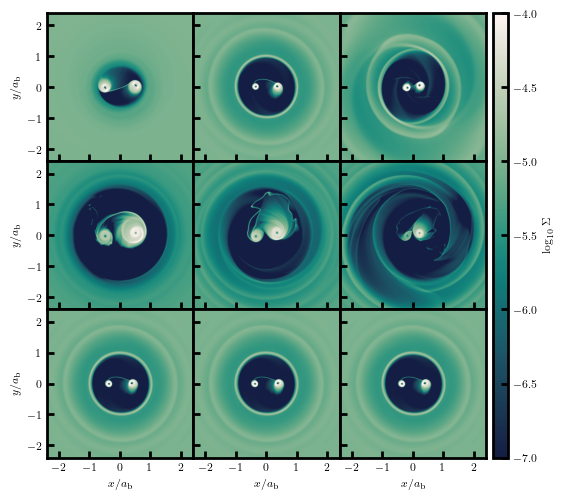

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(text_width, text_width), dpi=100,
                         sharex=True, sharey=True,
                         height_ratios=[0.33, 0.33, 0.33],
                         gridspec_kw={'hspace': 0.0, 'wspace': 0.0})
axes_flat = axes.flatten()


for index in range(9):
    ax     = axes_flat[index]
    chkpt  = data[Names[index]]

    mesh   = chkpt["mesh"]
    SS73   = chkpt["SS73"]
    Sigma  = chkpt["solution"][:, :, 0].T * SS73.Mdrop**(3./5.)

    extent = mesh.x0, mesh.x1, mesh.y0, mesh.y1
    cm     = ax.imshow(
                    np.log10(Sigma),
                    origin="lower",
                    vmin=-7.0,
                    vmax=-4.0,
                    cmap=cmocean.cm.tempo_r,
                    extent=extent
                    )
    ax.set_xlim(-2.4, 2.4)
    ax.set_ylim(-2.4, 2.4)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    ax.set_aspect('auto')

cax = inset_axes(axes[1, 2],  # anchor to middle-right panel
                 width="10%",
                 height="300%",  # spans 3 panels
                 loc="center right",
                 bbox_to_anchor=(0.15, 0, 1, 1),
                 bbox_transform=axes[1, 2].transAxes,
                 borderpad=0)

for ax in axes_flat:
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_major_locator(MultipleLocator(1))

cbar = fig.colorbar(cm, cax=cax)
cbar.set_label(r'$\log_{10} \Sigma$')
col_labels = [r'$x / a_\mathrm{b}$', r'$x / a_\mathrm{b}$', r'$x / a_\mathrm{b}$']
row_labels = [r'$y / a_\mathrm{b}$', r'$y / a_\mathrm{b}$', r'$y / a_\mathrm{b}$']

for col in range(3):
    axes[2, col].set_xlabel(col_labels[col])

for row in range(3):
    axes[row, 0].set_ylabel(row_labels[row])


plt.tight_layout()
#plt.show()
plt.savefig('DensityMaps.png', dpi = 400, bbox_inches='tight')

## Sweep Plotting

In [7]:
def ComputeBinnedStats(times, field, Averaging_Window):
    """Return bin centers, means, and 1-sigma standard deviations."""
    num_bins    = int(np.ceil((times[-1] - times[0]) / Averaging_Window))
    bin_edges   = np.linspace(times[0], times[-1], num_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_means   = np.zeros(num_bins)
    bin_stds    = np.zeros(num_bins)

    for i in range(num_bins):
        bin_mask = (times >= bin_edges[i]) & (times < bin_edges[i + 1])
        bin_data = field[bin_mask]
        if len(bin_data) > 1:
            bin_means[i] = np.mean(bin_data)
            bin_stds[i]  = np.std(bin_data)
        elif len(bin_data) == 1:
            bin_means[i] = bin_data[0]
            bin_stds[i]  = np.nan
        else:
            bin_means[i] = np.nan
            bin_stds[i]  = np.nan

    return bin_centers, bin_means, bin_stds

def ComputeAdotEdot(checkpoint):
    ts                  = DavidTimeseries(checkpoint)
    SS73                = ts.SS73
    M_dot_0             = SS73.Mdot_inf
    Final_Orbits        = ts.eccentricity[ts.eccentricity>0.0001]

    primary, secondary  = ts.pointmasses
    m1, m2              = primary.mass, secondary.mass
    M, G                = m1 + m2, 1.0
    q                   = m2 / m1                                            # mass ratio
    mu                  = m1 * m2 / M                                        # reduced mass
    Torque              = -(np.array(ts.torque_g[-len(Final_Orbits):]) + np.array(ts.torque_a[-len(Final_Orbits):])) / M_dot_0
    Power               = -(np.array(ts.power_g[-len(Final_Orbits):] ) + np.array(ts.power_a[-len(Final_Orbits):] )) / M_dot_0
    Accretion_1         = -(np.array(ts.mdot1[-len(Final_Orbits):])) / M_dot_0
    Accretion_2         = -(np.array(ts.mdot2[-len(Final_Orbits):])) / M_dot_0
    Mdot                = Accretion_1 + Accretion_2                          # total mass accretion rate
    a                   = np.array(ts.semimajor_axis[-len(Final_Orbits):])   # = a_rel (relative orbit semi-major axis)
    e                   = np.array(ts.eccentricity[-len(Final_Orbits):])
    E_Anomaly           = np.array([eccentric_anomaly(2*np.pi*Final_Orbits[ind], e[ind], a[ind], M) for ind in range(len(Final_Orbits))])
    cosE                = np.cos(E_Anomaly)
    ecosE               = e * cosE
    r_binary            = a * (1 - ecosE)                                    # binary separation
    E                   = - G * M * mu / (2*a)
    L                   = mu * np.sqrt(G * M * a * (1 - e**2))
    mudot               = Mdot * mu / M + (1 - q) * (Accretion_2 - q * Accretion_1) * mu / q / M
    v2                  = G * M * (2 / r_binary - 1 / a)
    Edot                = -0.5*mudot*v2 - G*M*mudot/r_binary - G*Mdot*mu / r_binary + Power
    Ldot                = Torque 
    adot                = Mdot / M + mudot / mu - Edot / E
    edot                = ((1-e**2) / (2*e+1e-5)) * (2*Mdot/M + 3*mudot/mu - 2*Ldot/L - Edot/E)
    return e, adot, edot

def ComputeLightcurves(checkpoint):
    ts                  = DavidTimeseries(checkpoint)
    SS73                = ts.SS73
    M_dot_0             = SS73.Mdot_inf
    n_final             = len(ts.eccentricity[ts.eccentricity > 0.0001])
    t_orbits            = np.array(ts.time[-n_final:])          # orbit count — correct time axis for LS

    return (
        ts.infared[-n_final:] / M_dot_0,
        ts.optical[-n_final:] / M_dot_0,
        ts.uv[-n_final:]      / M_dot_0,
        t_orbits
    )

Mach10Sweep = load_checkpoint('/mnt/beegfs/haimagrp/david_oneill/sailfish/Retrograde/Sweeps/Mach10/n5000/chkpt.0550.pk')
Mach20Sweep = load_checkpoint('/mnt/beegfs/haimagrp/david_oneill/sailfish/Retrograde/Sweeps/Mach20/n20000/chkpt.2367.pk')

Mach10_e, Mach10_adot, Mach10_edot = ComputeAdotEdot(Mach10Sweep)
Mach20_e, Mach20_adot, Mach20_edot = ComputeAdotEdot(Mach20Sweep)

Mach10_infared, Mach10_optical, Mach10_uv, Mach10_t = ComputeLightcurves(Mach10Sweep)
Mach20_infared, Mach20_optical, Mach20_uv, Mach20_t = ComputeLightcurves(Mach20Sweep)


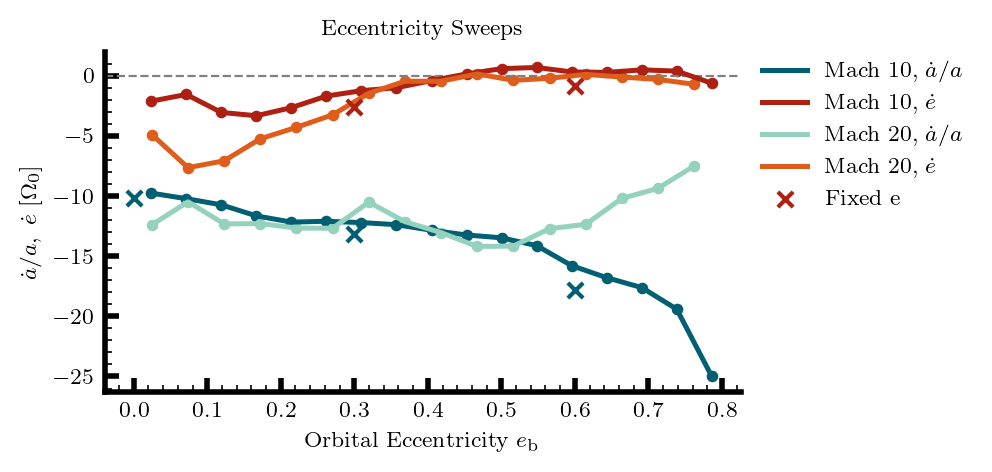

In [8]:
fig, ax  = plt.subplots(figsize=[text_width, column_width],  dpi=200)
savename = 'Sweep'

_adot_dark  = '#2166AC'  # deep blue
_adot_light = '#6BAED6'  # medium cornflower blue

_edot_dark  = '#B2182B'  # deep crimson
_edot_light = '#EF8A62'  # warm salmon-orange


_adot_dark  = '#2166AC'  # deep blue
_adot_light = '#74ADD1'  # sky blue

_edot_dark  = '#1A7B35'  # deep forest green
_edot_light = '#74C476'  # medium sage green


_adot_dark  = '#005F73'  # deep teal
_adot_light = '#94D2BD'  # pale teal

_edot_dark  = '#AE2012'  # deep brick red
_edot_light = '#E05C1A'  # amber-orange



Mach10_ea, Mach10_ma, _ = ComputeBinnedStats(Mach10_e, Mach10_adot, 0.05)
Mach10_ee, Mach10_me, _ = ComputeBinnedStats(Mach10_e, Mach10_edot, 0.05)
Mach20_ea, Mach20_ma, _ = ComputeBinnedStats(Mach20_e, Mach20_adot, 0.05)
Mach20_ee, Mach20_me, _ = ComputeBinnedStats(Mach20_e, Mach20_edot, 0.05)

ax.plot(Mach10_ea, Mach10_ma, linewidth=1.8, linestyle='solid', color=_adot_dark , label=r'Mach 10, $\dot{a}/a$', zorder=3)
ax.plot(Mach10_ee, Mach10_me, linewidth=1.8, linestyle='solid', color=_edot_dark , label=r'Mach 10, $\dot{e}$',   zorder=3)
ax.plot(Mach20_ea, Mach20_ma, linewidth=1.8, linestyle='solid', color=_adot_light, label=r'Mach 20, $\dot{a}/a$', zorder=3)
ax.plot(Mach20_ee, Mach20_me, linewidth=1.8, linestyle='solid', color=_edot_light, label=r'Mach 20, $\dot{e}$',  zorder=3)

ax.scatter(Mach10_ea, Mach10_ma, color=_adot_dark,  s = 10)
ax.scatter(Mach10_ee, Mach10_me, color=_edot_dark,  s = 10)
ax.scatter(Mach20_ea, Mach20_ma, color=_adot_light, s = 10)
ax.scatter(Mach20_ee, Mach20_me, color=_edot_light, s = 10)

ax.scatter(0.0, -10.14, color=_adot_dark, marker='x', s=30, zorder=4)
ax.scatter(0.3, -13.16, color=_adot_dark, marker='x', s=30, zorder=4)
ax.scatter(0.6, -17.81, color=_adot_dark, marker='x', s=30, zorder=4)
ax.scatter(0.3,  -2.59, color=_edot_dark, marker='x', s=30, zorder=4)
ax.scatter(0.6,  -0.84, color=_edot_dark, marker='x', s=30, zorder=4, label = 'Fixed e')

ax.autoscale()
_ylo, _yhi = ax.get_ylim()

ax.set_ylim(_ylo, _yhi)   
ax.axhline(y=0, color='0.5', linewidth=0.8, linestyle='--', zorder=2)

ax.set_xlabel('Orbital Eccentricity $e_\mathrm{b}$')
ax.set_ylabel(r'$\dot{a}/a,\ \dot{e}\ [\Omega_0]$')
ax.set_title(r'Eccentricity Sweeps', fontsize=8)
#ax.legend(loc='upper right', frameon=True, framealpha=0.9, edgecolor='none')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0,frameon=True, framealpha=0.9, edgecolor='none')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(which='both', top=False, right=False)
ax.minorticks_on()
ax.tick_params(which='minor', length=2.5, direction='in')
fig.tight_layout()


plt.tight_layout()
plt.savefig('Sweep', dpi=300)

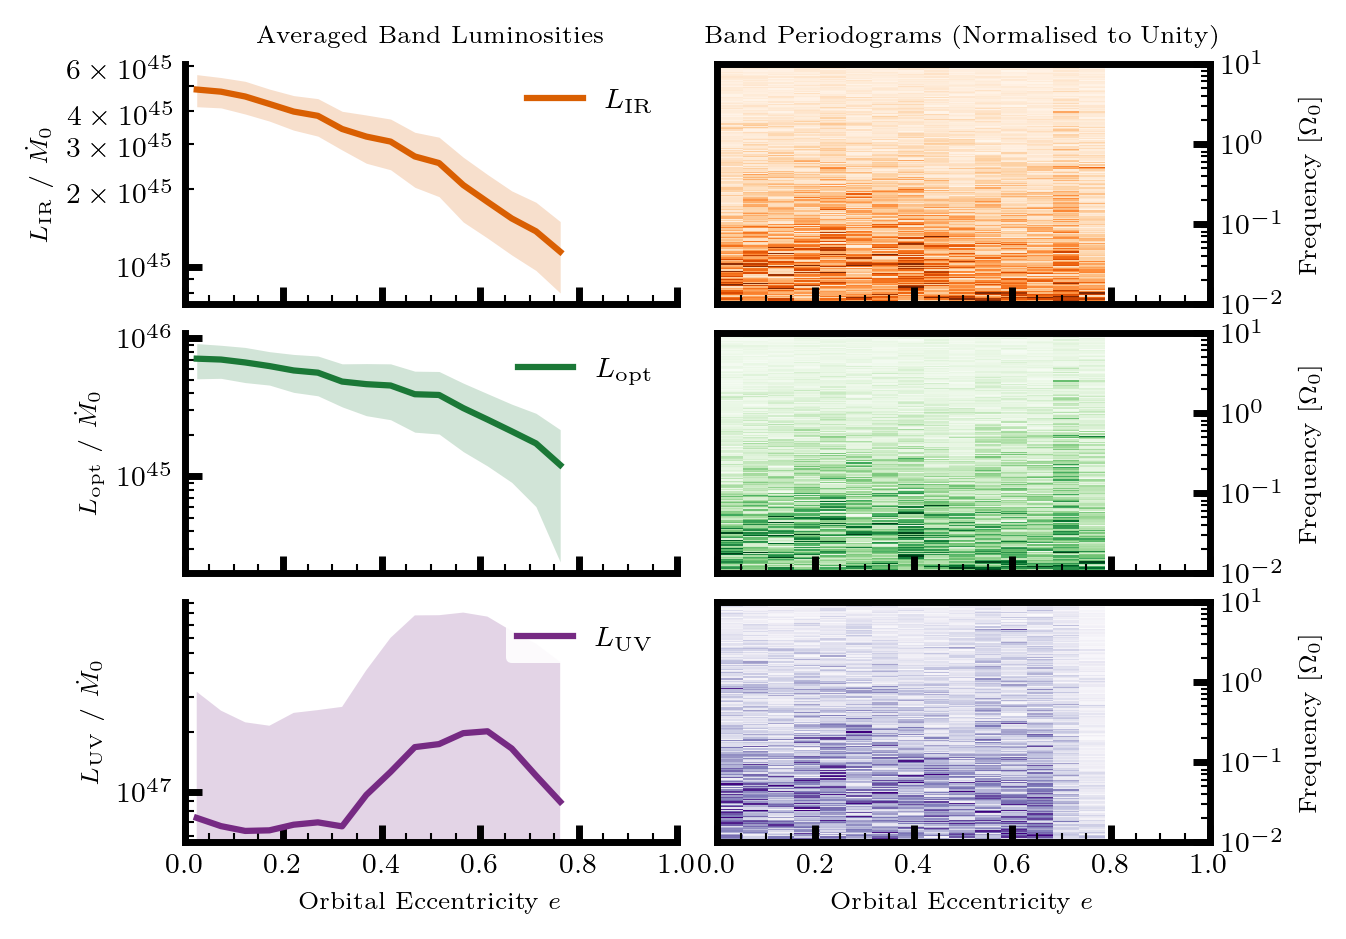

In [9]:
#infared, optical, uv, e, t = Mach10_infared, Mach10_optical, Mach10_uv, Mach10_e, Mach10_t
infared, optical, uv, e, t = Mach20_infared, Mach20_optical, Mach20_uv, Mach20_e, Mach20_t

delta_e = 0.05
e_f     = e[-1]

# --- EM panels: L(e) line (left) + 2D LS spectrogram P(e, f) (right) ---
_bands = [
    (infared,  r'$L_\mathrm{IR}$',  r'$L_\mathrm{IR}\ /\ \dot{M}_0$',  '#D95F02', 'Oranges'),
    (optical,  r'$L_\mathrm{opt}$', r'$L_\mathrm{opt}\ /\ \dot{M}_0$', '#1B7837', 'Greens' ),
    (uv     ,  r'$L_\mathrm{UV}$',  r'$L_\mathrm{UV}\ /\ \dot{M}_0$',  '#762A83', 'Purples'),
]

# eccentricity bins for the 2D spectrogram 
_n_e      = int(e_f / delta_e)
_e_edges  = np.linspace(0.0, e_f, _n_e + 1)
_e_ctrs   = 0.5 * (_e_edges[:-1] + _e_edges[1:])
_freq_2d  = np.logspace(-2, 1, 200)           # cycles / orbit, 0.1 – 10
_omega_2d = 2.0 * np.pi * _freq_2d
_min_samp = 5                                 # min points per bin for reliable LS

# pre-compute L(e) stats and per-bin periodograms for each band
_band_stats = []
for lum, band_label, ylabel, color, cmap in _bands:
    ec, lm, ls = ComputeBinnedStats(e, lum, delta_e)
    power_2d   = np.full((_n_e, len(_freq_2d)), np.nan)

    for j in range(_n_e):
        mask = (e >= _e_edges[j]) & (e < _e_edges[j + 1])
        if mask.sum() >= _min_samp:
            t_bin   = t[mask]
            sig_bin = lum[mask] - np.mean(lum[mask])
            var_bin = np.var(sig_bin)
            if var_bin > 0:
                p          = lombscargle(t_bin, sig_bin, _omega_2d)
                p         /= var_bin          # normalised LS
                p         /= np.nanmax(p)     # row-normalise → [0, 1]
                power_2d[j] = p

    _band_stats.append((ec, lm, ls, power_2d, band_label, ylabel, color, cmap))





fig2 = plt.figure(figsize=[text_width, text_width * 0.75], dpi = 250)
gs   = fig2.add_gridspec(3, 2, width_ratios=[1.0, 1.0],
                            hspace=0.12, wspace=0.08,
                            left=0.10, right=0.92, top=0.93, bottom=0.10)

ax_lum_ref = None
ax_per_ref = None
last_im    = None

for i, (ec, lm, ls, power_2d, band_label, ylabel, color, cmap) in enumerate(_band_stats):

    ax_lum = fig2.add_subplot(gs[i, 0], sharex=ax_lum_ref)
    ax_per = fig2.add_subplot(gs[i, 1], sharex=ax_per_ref)
    if ax_lum_ref is None:
        ax_lum_ref = ax_lum
    if ax_per_ref is None:
        ax_per_ref = ax_per

    # left: mean luminosity ± 1σ vs eccentricity
    ax_lum.fill_between(ec, lm - ls, lm + ls,
                            color=color, alpha=0.2, linewidth=0, zorder=1)
    ax_lum.plot(ec, lm, linewidth=1.8, color=color, label=band_label, zorder=3)
    ax_lum.set_yscale('log')
    ax_lum.set_ylabel(ylabel, fontsize=7)
    ax_lum.set_xlim(0.0, 1.0)
    ax_lum.legend(loc='upper right', frameon=True, framealpha=0.9, edgecolor='none')
    ax_lum.spines['top'].set_visible(False)
    ax_lum.spines['right'].set_visible(False)
    ax_lum.tick_params(which='both', top=False, right=False)
    ax_lum.minorticks_on()
    ax_lum.tick_params(which='minor', length=2.5, direction='in')
    if i < 2:
        ax_lum.tick_params(labelbottom=False)

    from matplotlib.colors import PowerNorm
    im = ax_per.pcolormesh(_e_ctrs, _freq_2d, power_2d.T,
                            cmap=cmap, shading='auto', rasterized=True,
                            norm=PowerNorm(gamma=0.4, vmin=0.0, vmax=1.0))
    last_im = im
    ax_per.set_yscale('log')
    ax_per.set_ylim(_freq_2d[0], _freq_2d[-1])
    ax_per.set_xlim(0.0, 1.0)
    ax_per.set_ylabel(r'Frequency $[\Omega_0]$', fontsize=7)
    ax_per.yaxis.set_label_position('right')
    ax_per.yaxis.tick_right()
    ax_per.tick_params(which='both', top=False, left=False)
    ax_per.minorticks_on()
    ax_per.tick_params(which='minor', length=2.5, direction='in')

    if i == 0:
        ax_lum.set_title('Averaged Band Luminosities', fontsize=7)
        ax_per.set_title('Band Periodograms (Normalised to Unity)', fontsize=7)

    if i == 2:
        ax_lum.set_xlabel(r'Orbital Eccentricity $e$', fontsize=7)
        ax_per.set_xlabel(r'Orbital Eccentricity $e$', fontsize=7)
    else:
        ax_lum.tick_params(labelbottom=False)
        ax_per.tick_params(labelbottom=False)

plt.savefig('Mach20_Emission.png', bbox_inches='tight')

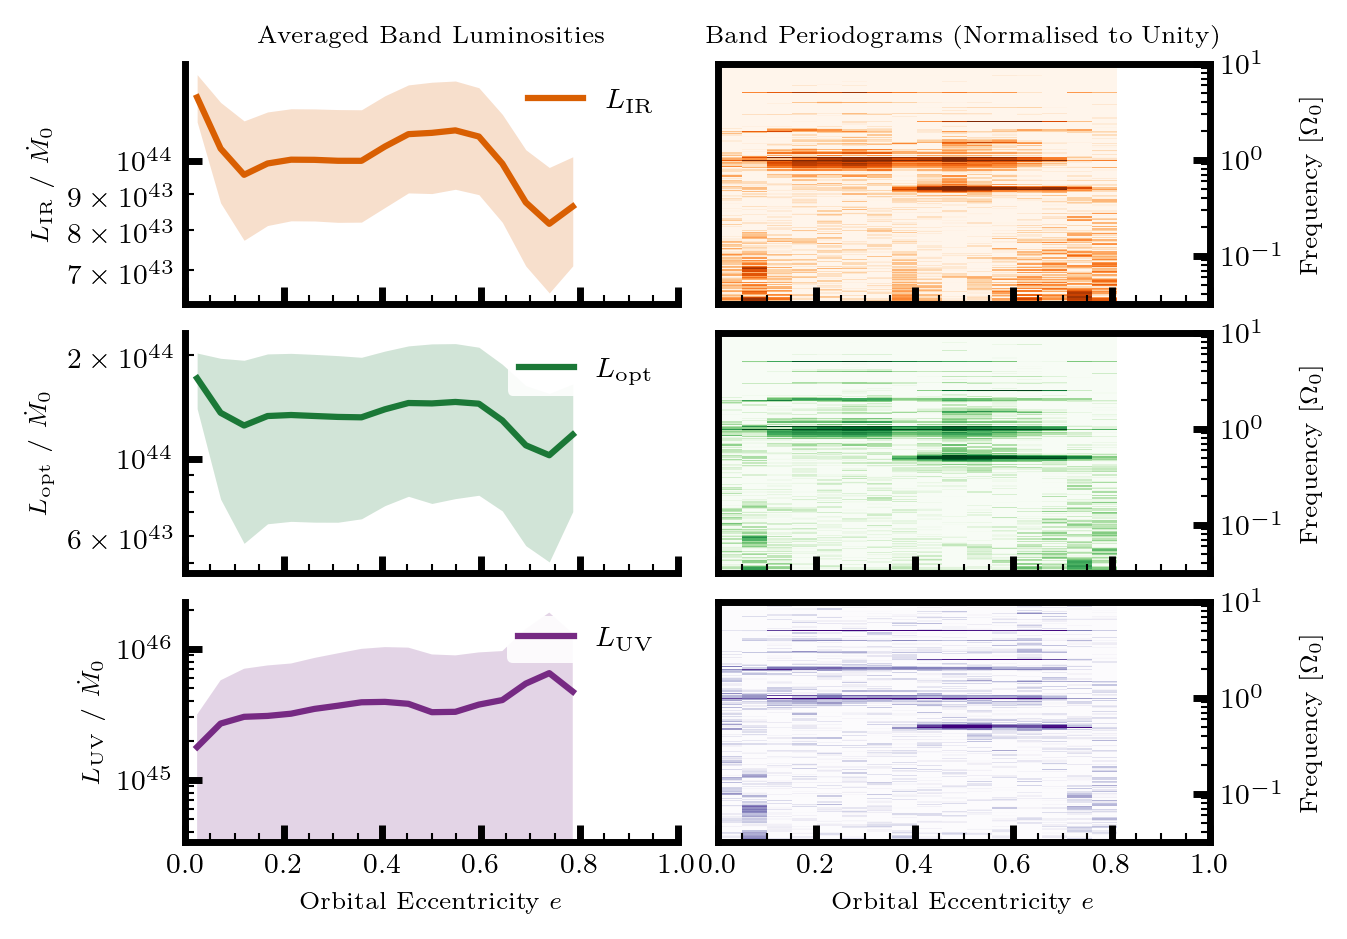

In [ ]:
Mach20 = True

if Mach20:
    infared, optical, uv, e, t = Mach20_infared, Mach20_optical, Mach20_uv, Mach20_e, Mach20_t
else:
    infared, optical, uv, e, t = Mach10_infared, Mach10_optical, Mach10_uv, Mach10_e, Mach10_t

delta_e = 0.05
e_f     = e[-1]

# --- EM panels: L(e) line (left) + 2D LS spectrogram P(e, f) (right) ---
_bands = [
    (infared,  r'$L_\mathrm{IR}$',  r'$L_\mathrm{IR}\ /\ \dot{M}_0$',  '#D95F02', 'Oranges'),
    (optical,  r'$L_\mathrm{opt}$', r'$L_\mathrm{opt}\ /\ \dot{M}_0$', '#1B7837', 'Greens' ),
    (uv     ,  r'$L_\mathrm{UV}$',  r'$L_\mathrm{UV}\ /\ \dot{M}_0$',  '#762A83', 'Purples'),
]

# eccentricity bins for the 2D spectrogram 
_n_e      = int(e_f / delta_e)
_e_edges  = np.linspace(0.0, e_f, _n_e + 1)
_e_ctrs   = 0.5 * (_e_edges[:-1] + _e_edges[1:])
_freq_2d  = np.logspace(-1.5, 1, 200)           # cycles / orbit, 0.1 – 10
_omega_2d = 2.0 * np.pi * _freq_2d
_min_samp = 5                                    # min points per bin for reliable LS

# pre-compute L(e) stats and per-bin periodograms for each band
_band_stats = []
for lum, band_label, ylabel, color, cmap in _bands:
    ec, lm, ls = ComputeBinnedStats(e, lum, delta_e)
    power_2d   = np.full((_n_e, len(_freq_2d)), np.nan)

    for j in range(_n_e):
        mask = (e >= _e_edges[j]) & (e < _e_edges[j + 1])
        if mask.sum() >= _min_samp:
            t_bin   = t[mask]
            sig_bin = lum[mask] - np.mean(lum[mask])
            var_bin = np.var(sig_bin)
            if var_bin > 0:
                p          = lombscargle(t_bin, sig_bin, _omega_2d)
                p         /= var_bin          # Scargle-normalised LS power
                med        = np.median(p)
                if med > 0:
                    p /= med                  # excess above noise floor; stable w.r.t. freq resolution
                power_2d[j] = p

    _band_stats.append((ec, lm, ls, power_2d, band_label, ylabel, color, cmap))

fig2 = plt.figure(figsize=[text_width, text_width * 0.75], dpi = 250)
gs   = fig2.add_gridspec(3, 2, width_ratios=[1.0, 1.0],
                            hspace=0.12, wspace=0.08,
                            left=0.10, right=0.92, top=0.93, bottom=0.10)

ax_lum_ref = None
ax_per_ref = None
last_im    = None

for i, (ec, lm, ls, power_2d, band_label, ylabel, color, cmap) in enumerate(_band_stats):

    ax_lum = fig2.add_subplot(gs[i, 0], sharex=ax_lum_ref)
    ax_per = fig2.add_subplot(gs[i, 1], sharex=ax_per_ref)
    if ax_lum_ref is None:
        ax_lum_ref = ax_lum
    if ax_per_ref is None:
        ax_per_ref = ax_per

    # left: mean luminosity ± 1σ vs eccentricity
    ax_lum.fill_between(ec, lm - ls, lm + ls,
                            color=color, alpha=0.2, linewidth=0, zorder=1)
    ax_lum.plot(ec, lm, linewidth=1.8, color=color, label=band_label, zorder=3)
    ax_lum.set_yscale('log')
    ax_lum.set_ylabel(ylabel, fontsize=7)
    ax_lum.set_xlim(0.0, 1.0)
    ax_lum.legend(loc='upper right', frameon=True, framealpha=0.9, edgecolor='none')
    ax_lum.spines['top'].set_visible(False)
    ax_lum.spines['right'].set_visible(False)
    ax_lum.tick_params(which='both', top=False, right=False)
    ax_lum.minorticks_on()
    ax_lum.tick_params(which='minor', length=2.5, direction='in')
    
    if i < 2:
        ax_lum.tick_params(labelbottom=False)

    from matplotlib.colors import LogNorm
    valid = power_2d[np.isfinite(power_2d) & (power_2d > 0)]
    vmin  = 1.0    # or just fix at 1.0 since you median-normalised
    vmax  = np.percentile(valid, 99)   # captures the bulk without being blown out by spikes
    norm  = LogNorm(vmin=vmin, vmax=vmax)
    im      = ax_per.pcolormesh(_e_ctrs, _freq_2d, power_2d.T, cmap=cmap, shading='auto', rasterized=True, norm=norm)
    last_im = im
    ax_per.set_yscale('log')
    ax_per.set_ylim(_freq_2d[0], _freq_2d[-1])
    ax_per.set_xlim(0.0, 1.0)
    ax_per.set_ylabel(r'Frequency $[\Omega_0]$', fontsize=7)
    ax_per.yaxis.set_label_position('right')
    ax_per.yaxis.tick_right()
    ax_per.tick_params(which='both', top=False, left=False)
    ax_per.minorticks_on()
    ax_per.tick_params(which='minor', length=2.5, direction='in')

    if i == 0:
        ax_lum.set_title('Averaged Band Luminosities', fontsize=7)
        ax_per.set_title('Band Periodograms (Normalised to Unity)', fontsize=7)

    if i == 2:
        ax_lum.set_xlabel(r'Orbital Eccentricity $e$', fontsize=7)
        ax_per.set_xlabel(r'Orbital Eccentricity $e$', fontsize=7)
    else:
        ax_lum.tick_params(labelbottom=False)
        ax_per.tick_params(labelbottom=False)


if 
plt.savefig('Mach20_Emission.png', bbox_inches='tight')


## Disk Profiles

In [16]:
chkpt      = load_checkpoint('/mnt/beegfs/haimagrp/david_oneill/sailfish/Retrograde/Sweeps/Mach20/n20000/chkpt.0400.pk')
SS73       = chkpt["SS73"]
mesh       = chkpt["mesh"]
Sigma      = chkpt["solution"][:, :, 0].T 
Vx         = chkpt['solution'][:, :, 1].T
Vy         = chkpt['solution'][:, :, 2].T
Pressure   = chkpt["solution"][:, :, 3].T 
gamma      = chkpt['model_parameters']['gamma_law_index']
cs         = (gamma * Pressure / Sigma)**0.5
ni, nj     = mesh.shape
x          = np.array([mesh.cell_coordinates(i, 0)[0] for i in range(ni)])
y          = np.array([mesh.cell_coordinates(0, j)[1] for j in range(nj)])
X, Y       = np.meshgrid(x, y, indexing="xy")
Nbins      = int(100)
RadialBins = np.linspace(1.0, mesh.x1, Nbins)
Sigma     *= SS73.surface_density_coefficient # in units of Mb/a0^2
radius     = np.sqrt( X**2 +  Y**2)
Radius     = RadialBins[1:]
speed      = np.sqrt(Vx**2 + Vy**2)
v_dot_v    = speed**2
v_dot_r    = Vx*X + Vy*Y
ex         = (v_dot_v * X - v_dot_r * Vx) - X / radius
ey         = (v_dot_v * Y - v_dot_r * Vy) - Y / radius
e          = np.sqrt(ex**2 + ey**2)
mach       = speed/cs
DiskStats  = {'MeanV': [], 'MinV': [], 'MaxV': [], 'MeanE': [], 'MinE': [], 'MaxE': [], 'MeanD': [], 'MinD': [], 'MaxD': [], 'MeanM': [], 'MinM': [], 'MaxM': []}

def SaveBinStats(dictname, keys, args):
     for (key, arg) in zip(keys, args):
          dictname[key].append(arg)

for i in range(len(RadialBins)-1):
     mask           = (RadialBins[i] < radius) & (radius < RadialBins[i+1])
     N              = np.sum(mask)
     speed_mask     = speed[mask]
     e_mask         = e[mask]
     density_mask   = Sigma[mask]
     mach_mask      = mach[mask]

     SaveBinStats(
          DiskStats,
          ['MeanV', 'MinV', 'MaxV', 'MeanE', 'MinE', 'MaxE', 'MeanD', 'MinD', 'MaxD', 'MeanM', 'MinM', 'MaxM'], 
          [np.mean(speed_mask)  , np.min(speed_mask)  , np.max(speed_mask),
          np.mean(e_mask)      , np.min(e_mask)      , np.max(e_mask),
          np.mean(density_mask), np.min(density_mask), np.max(density_mask), 
          np.mean(mach_mask)   , np.min(mach_mask)   , np.max(mach_mask)]
     )


# --- Minidisk Profile Analysis ---
RMinidisk          = 0.5
primary, secondary = chkpt['point_masses']
SinkRadius         = (primary.sink_radius,      secondary.sink_radius)
SoftRadius         = (primary.softening_length, secondary.softening_length)
RadialBins_md      = np.linspace(0, RMinidisk, int((RMinidisk / (mesh.x1 - mesh.x0)) * ni))
GMu_primary        = primary.mass
GMu_secondary      = secondary.mass

r_primary        = [X - primary.position_x,    Y - primary.position_y]
r_secondary      = [X - secondary.position_x,  Y - secondary.position_y]
V_primary        = [Vx - primary.velocity_x,   Vy - primary.velocity_y]
V_secondary      = [Vx - secondary.velocity_x, Vy - secondary.velocity_y]
primary_speed    = np.sqrt(V_primary[0]**2   + V_primary[1]**2)
secondary_speed  = np.sqrt(V_secondary[0]**2 + V_secondary[1]**2)
primary_radius   = np.sqrt(r_primary[0]**2   + r_primary[1]**2)
secondary_radius = np.sqrt(r_secondary[0]**2 + r_secondary[1]**2)

v_dot_v_primary   = primary_speed**2
v_dot_r_primary   = V_primary[0] * r_primary[0]  + V_primary[1] * r_primary[1]
ex_primary        = (v_dot_v_primary * r_primary[0]  - v_dot_r_primary * V_primary[0])  / GMu_primary  - r_primary[0]  / primary_radius
ey_primary        = (v_dot_v_primary * r_primary[1]  - v_dot_r_primary * V_primary[1])  / GMu_primary  - r_primary[1]  / primary_radius
e_primary         = np.sqrt(ex_primary**2  + ey_primary**2)
mach_primary      = primary_speed / cs
v_dot_v_secondary = secondary_speed**2
v_dot_r_secondary = V_secondary[0] * r_secondary[0] + V_secondary[1] * r_secondary[1]
ex_secondary      = (v_dot_v_secondary * r_secondary[0] - v_dot_r_secondary * V_secondary[0]) / GMu_secondary - r_secondary[0] / secondary_radius
ey_secondary      = (v_dot_v_secondary * r_secondary[1] - v_dot_r_secondary * V_secondary[1]) / GMu_secondary - r_secondary[1] / secondary_radius
e_secondary       = np.sqrt(ex_secondary**2 + ey_secondary**2)
mach_secondary    = secondary_speed / cs

keys              = ['MeanV','MinV','MaxV','MeanE','MinE','MaxE','MeanD','MinD','MaxD','MeanM','MinM','MaxM']
PrimaryMiniDisk   = {k: [] for k in keys}
SecondaryMiniDisk = {k: [] for k in keys}
for i in range(len(RadialBins_md) - 1):
    pm = (RadialBins_md[i] < primary_radius)   & (primary_radius   < RadialBins_md[i+1])
    sm = (RadialBins_md[i] < secondary_radius) & (secondary_radius < RadialBins_md[i+1])
    SaveBinStats(PrimaryMiniDisk, keys,
        [np.mean(primary_speed[pm]),  np.min(primary_speed[pm]),  np.max(primary_speed[pm]),
         np.mean(e_primary[pm]),      np.min(e_primary[pm]),      np.max(e_primary[pm]),
         np.mean(Sigma[pm]),          np.min(Sigma[pm]),           np.max(Sigma[pm]),
         np.mean(mach_primary[pm]),   np.min(mach_primary[pm]),   np.max(mach_primary[pm])])
    SaveBinStats(SecondaryMiniDisk, keys,
        [np.mean(secondary_speed[sm]), np.min(secondary_speed[sm]), np.max(secondary_speed[sm]),
         np.mean(e_secondary[sm]),     np.min(e_secondary[sm]),     np.max(e_secondary[sm]),
         np.mean(Sigma[sm]),           np.min(Sigma[sm]),            np.max(Sigma[sm]),
         np.mean(mach_secondary[sm]),  np.min(mach_secondary[sm]),  np.max(mach_secondary[sm])])



/tmp/ipykernel_3961389/2227339215.py:53: RuntimeWarning: invalid value encountered in power
  Mach_profile_l0 = Radius**(-1/20) * f0**(-0.2)
/tmp/ipykernel_3961389/2227339215.py:70: RuntimeWarning: invalid value encountered in power
  Sigma_profile_l0 = Radius**(-3/5) * f0**0.6


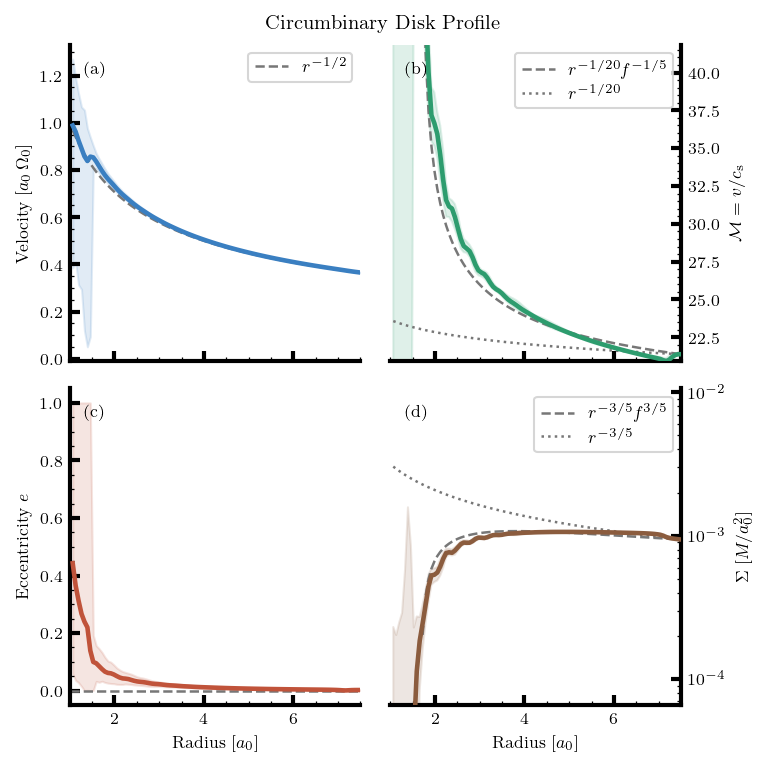

In [17]:
_c_vel   = '#3A7FC1'   # slate blue     — velocity
_c_mach  = '#2D9C6E'   # sage green     — Mach number
_c_ecc   = '#C0533A'   # terracotta     — eccentricity
_c_sigma = '#8B5C3E'   # dusty purple   — surface density
_c_ref   = '#777777'   # mid grey       — theory curves

fig = plt.figure(figsize=(1.0 * text_width, 1.0 * text_width), dpi=150)
fig.set_layout_engine('constrained')
gs  = fig.add_gridspec(2, 2, hspace=0.05, wspace=0.08)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# --- shared log x-axis and clean spines on all panels ---
for ax in (ax1, ax2, ax3, ax4):
    #ax.set_xscale('log')
    ax.set_xlim([RadialBins[0], mesh.x1])
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(which='both', direction='in', top=False, right=False)
    ax.minorticks_on()

# suppress x tick labels on top row
for ax in (ax1, ax2):
    ax.tick_params(labelbottom=False)

# right-hand column: ticks and label on right spine
for ax in (ax2, ax4):
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position('right')
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(True)
    ax.tick_params(which='both', direction='in', right=True, left=False)

# shared x-label on bottom panels only
for ax in (ax3, ax4):
    ax.set_xlabel(r'Radius $[a_0]$')

# panel corner labels
for ax, lbl in zip((ax1, ax2, ax3, ax4), 'abcd'):
    ax.text(0.05, 0.95, f'({lbl})', transform=ax.transAxes, fontsize=8, fontweight='bold', va='top', zorder=4)

f0 = np.array([(1 - 1.3 * np.sqrt(1/radi)) if np.sqrt(radi) > 1 else 1 for radi in Radius])

# --- (a) Velocity ---
ax1.plot(Radius, DiskStats['MeanV'], color=_c_vel, linewidth=2.2, zorder=3)
ax1.plot(Radius, [np.sqrt(1/r) for r in RadialBins[1:]], color=_c_ref, linestyle='dashed', linewidth=1.2, label=r'$r^{-1/2}$', zorder=2)
ax1.fill_between(Radius, DiskStats['MinV'], DiskStats['MaxV'], color=_c_vel, alpha=0.15, zorder=1)
ax1.legend()
ax1.set_ylabel(r'Velocity $[a_0\,\Omega_0]$')

# --- (b) Mach number ---
Mach_profile_l0 = Radius**(-1/20) * f0**(-0.2)
Mach_profile_SS = Radius**(-1/20) 
ax2.plot(Radius, DiskStats['MeanM'], color=_c_mach, linewidth=2.2, zorder=3)
ax2.plot(Radius, DiskStats['MeanM'][-1] * Mach_profile_l0 / Mach_profile_l0[-1], color=_c_ref, linestyle='dashed', linewidth=1.2, label=r'$r^{-1/20}f^{-1/5}$', zorder=2)
ax2.plot(Radius, DiskStats['MeanM'][-1] * Mach_profile_SS / Mach_profile_SS[-1], color=_c_ref, linestyle='dotted', linewidth=1.2, label=r'$r^{-1/20}$', zorder=2)
ax2.fill_between(Radius, DiskStats['MinM'], DiskStats['MaxM'], color=_c_mach, alpha=0.15, zorder=1)
ax2.set_ylim([np.min(DiskStats['MeanM']), np.min([np.max(DiskStats['MeanM']), 2*np.min(DiskStats['MeanM'])])])
ax2.legend()
ax2.set_ylabel(r'$\mathcal{M} = v/c_\mathrm{s}$')

# --- (c) Eccentricity ---
ax3.plot(Radius, DiskStats['MeanE'], color=_c_ecc, linewidth=2.2, zorder=3)
ax3.axhline(y=0, color=_c_ref, linestyle='dashed', linewidth=1.2, label=r'$e = 0$', zorder=2)
ax3.fill_between(Radius, DiskStats['MinE'], DiskStats['MaxE'], color=_c_ecc, alpha=0.15, zorder=1)
ax3.set_ylabel(r'Eccentricity $e$')

# --- (d) Surface density ---
Sigma_profile_l0 = Radius**(-3/5) * f0**0.6
Sigma_profile_SS = Radius**(-3/5)
SS73_coeff       = DiskStats['MeanD'][-1] / Radius[-1]**(-3/5)
ax4.plot(Radius, DiskStats['MeanD'], color=_c_sigma, linewidth=2.2, zorder=3)
ax4.plot(Radius, DiskStats['MeanD'][-1] * Sigma_profile_l0 / Sigma_profile_l0[-1], color=_c_ref, linestyle='dashed', linewidth=1.2, label=r'$r^{-3/5}f^{3/5}$', zorder=2)
ax4.plot(Radius, DiskStats['MeanD'][-1] * Sigma_profile_SS / Sigma_profile_SS[-1], color=_c_ref, linestyle='dotted', linewidth=1.2, label=r'$r^{-3/5}$', zorder=2)
ax4.fill_between(Radius, DiskStats['MinD'], DiskStats['MaxD'], color=_c_sigma, alpha=0.15, zorder=1)
ax4.set_ylim([100 * np.min(DiskStats['MeanD']), 10 * np.max(DiskStats['MeanD'])])
ax4.legend()
ax4.set_ylabel(r'$\Sigma\;[M/a_0^2]$')
ax4.set_yscale('log')

# # --- single unified legend at bottom ---
# handles, labels = [], []
# for ax in (ax1, ax2, ax3, ax4):
#     for h, l in zip(*ax.get_legend_handles_labels()):
#         if l not in labels:
#             handles.append(h)
#             labels.append(l)
# fig.legend(handles, labels, loc='outside lower center', ncol=4, frameon=False, fontsize=7)

fig.suptitle('Circumbinary Disk Profile')

plt.show()
#plt.savefig(f"Axisymmetry_{chkpt['time'] / 2 / np.pi:.2f}.png", dpi=400, bbox_inches='tight')

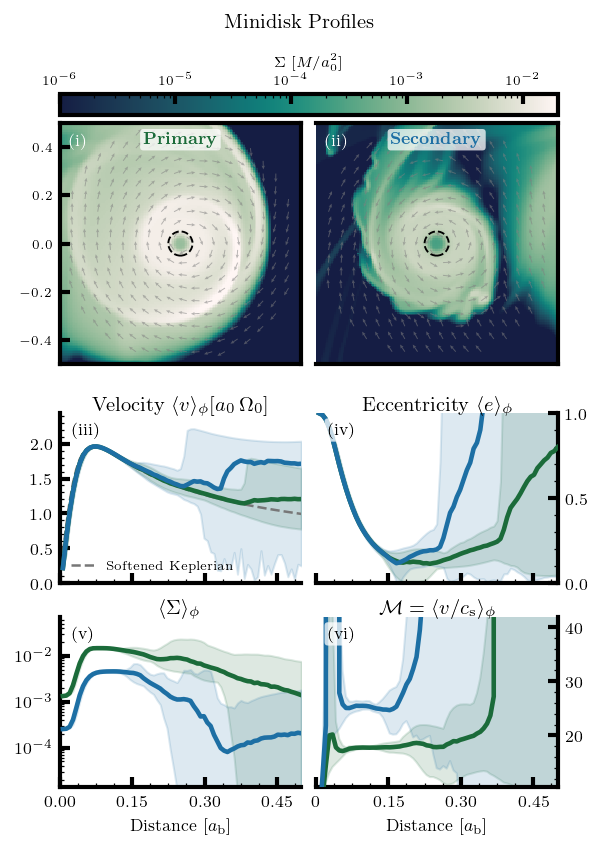

In [ ]:
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle

vlim            = 1.1 * np.nanmax([np.nanmax(PrimaryMiniDisk['MaxV']),  np.nanmax(SecondaryMiniDisk['MaxV'])])
dlim            = 3.0 * np.nanmax([np.nanmax(PrimaryMiniDisk['MaxD']),  np.nanmax(SecondaryMiniDisk['MaxD'])])
PrimaryRadius   = RadialBins_md[1:] #/ SinkRadius[0]
SecondaryRadius = RadialBins_md[1:] #/ SinkRadius[1]
xlim            = max(PrimaryRadius[-1], SecondaryRadius[-1])

_c_primary   = '#1B6B3A'
_c_secondary = '#1D6FA4'
_c_ref       = '#777777'

_sig_vals = np.concatenate([Sigma[primary_radius < RMinidisk].ravel(), Sigma[secondary_radius < RMinidisk].ravel()])
_sig_vals = _sig_vals[_sig_vals > 0]
_norm     = LogNorm(vmin=1e-6, vmax=2e-2)
_mach_all = np.concatenate([PrimaryMiniDisk['MeanM'], SecondaryMiniDisk['MeanM']])
_mac_max  = np.nanpercentile(_mach_all, 90) * 1.3
_mac_min  = 0.0

def _quiver_field(pos_x, pos_y, vel_x, vel_y):
    from scipy.interpolate import RegularGridInterpolator
    _nq   = 20
    _qgrd = np.linspace(-RMinidisk, RMinidisk, _nq)
    _qX, _qY = np.meshgrid(_qgrd, _qgrd)
    rgi_u = RegularGridInterpolator((y, x), vel_x, method='linear', bounds_error=False, fill_value=np.nan)
    rgi_v = RegularGridInterpolator((y, x), vel_y, method='linear', bounds_error=False, fill_value=np.nan)
    pts   = np.column_stack([(_qY + pos_y).ravel(), (_qX + pos_x).ravel()])
    U = rgi_u(pts).reshape(_nq, _nq)
    V = rgi_v(pts).reshape(_nq, _nq)
    R   = np.sqrt(_qX**2 + _qY**2)
    spd = np.sqrt(U**2 + V**2)
    spd[spd == 0] = np.nan
    U = np.where(R < RMinidisk, U / spd, np.nan)
    V = np.where(R < RMinidisk, V / spd, np.nan)
    return _qX, _qY, U, V

_qX_p, _qY_p, _qU_p, _qV_p = _quiver_field(primary.position_x,   primary.position_y,   Vx, Vy)
_qX_s, _qY_s, _qU_s, _qV_s = _quiver_field(secondary.position_x, secondary.position_y, Vx, Vy)

fig = plt.figure(figsize=(0.8*text_width, 1.12 * text_width), dpi=150)

gs_top = fig.add_gridspec(1, 2, left=0.10, right=0.93, top=0.925, bottom=0.609, wspace=0.06)
gs_bot = fig.add_gridspec(2, 2, left=0.10, right=0.93, top=0.565, bottom=0.12, hspace=0.20, wspace=0.06)

ax_pm  = fig.add_subplot(gs_top[0, 0])
ax_sm  = fig.add_subplot(gs_top[0, 1])
ax_vel = fig.add_subplot(gs_bot[0, 0])
ax_ecc = fig.add_subplot(gs_bot[0, 1])
ax_den = fig.add_subplot(gs_bot[1, 0])
ax_mac = fig.add_subplot(gs_bot[1, 1])

# --- (i, ii) density maps ---
for ax, pos_x, pos_y, title, c, sr, lbl, qX, qY, qU, qV in [
        (ax_pm, primary.position_x,   primary.position_y,   r'$\textbf{Primary}$',   _c_primary,   SinkRadius[0], 'i',  _qX_p, _qY_p, _qU_p, _qV_p),
        (ax_sm, secondary.position_x, secondary.position_y, r'$\textbf{Secondary}$', _c_secondary, SinkRadius[1], 'ii', _qX_s, _qY_s, _qU_s, _qV_s)]:
    im = ax.pcolormesh(X - pos_x, Y - pos_y, Sigma, cmap=cmocean.cm.tempo_r, norm=_norm, shading='auto', rasterized=True)
    ax.set_xlim([-RMinidisk, RMinidisk])
    ax.set_ylim([-RMinidisk, RMinidisk])
    ax.set_aspect('equal')
    ax.tick_params(which='both', direction='in', labelsize=6, bottom=False, labelbottom=False)
    ax.quiver(qX, qY, qU, qV, color='grey', alpha=0.55, scale=28, width=0.004, headwidth=3.5, headlength=4, headaxislength=3.5, zorder=4)
    ax.add_patch(Circle((0, 0), sr, fill=False, edgecolor='black', linewidth=0.9, linestyle='dashed', zorder=5))
    ax.text(0.50, 0.96, title, transform=ax.transAxes, fontsize=8, fontweight='bold', va='top', ha='center', color=c, zorder=6, bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.2'))
    ax.text(0.04, 0.96, f'({lbl})', transform=ax.transAxes, fontsize=8, fontweight='bold', va='top', color='white', zorder=7)

#ax_pm.set_ylabel(r'$\Delta y\;[a_\mathrm{b}]$', fontsize=7)
ax_sm.tick_params(left=False, labelleft=False)
ax_sm.spines['left'].set_visible(False)



cax = fig.add_axes([0.10, 0.92, 0.83, 0.025])
cb  = fig.colorbar(im, cax=cax, orientation='horizontal', location='top')
#cb = fig.colorbar(im, ax=[ax_pm, ax_sm], location='top', shrink=1.0, pad=0.02, aspect=25)
cb.set_label(r'$\Sigma\;[M/a_0^2]$', fontsize=7)
cb.ax.tick_params(labelsize=6)

# --- profile panel style ---
for ax in (ax_vel, ax_ecc, ax_den, ax_mac):
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(which='both', direction='in', top=False, right=False)
    ax.minorticks_on()

for ax in (ax_ecc, ax_mac):
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position('right')
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(True)
    ax.tick_params(which='both', direction='in', right=True, left=False)

for ax in (ax_vel, ax_ecc):
    ax.tick_params(labelbottom=False)

for ax in (ax_den, ax_mac):
    ax.set_xlabel(r'Distance $[a_\mathrm{b}]$')

# shared xticks on all four profile panels
for ax in (ax_vel, ax_ecc, ax_den, ax_mac):
    ax.set_xticks([0, 0.15, 0.3, 0.45])

for ax, lbl in zip((ax_vel, ax_ecc, ax_den, ax_mac), ('iii', 'iv', 'v', 'vi')):
    ax.text(0.05, 0.95, f'({lbl})', transform=ax.transAxes, fontsize=8, fontweight='bold', va='top', zorder=10, bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.2'))

ax_mac.set_xlim([0, xlim])

# --- (iii) Velocity ---
ax_vel.set_xlim([0, xlim])
ax_vel.set_ylim([0, vlim])
ax_vel.plot(PrimaryRadius,   PrimaryMiniDisk['MeanV'],   color=_c_primary,   linewidth=2.2, zorder=3)
ax_vel.plot(SecondaryRadius, SecondaryMiniDisk['MeanV'], color=_c_secondary, linewidth=2.2, zorder=3)
ax_vel.fill_between(PrimaryRadius,   PrimaryMiniDisk['MinV'],   PrimaryMiniDisk['MaxV'],   color=_c_primary,   alpha=0.15, zorder=1)
ax_vel.fill_between(SecondaryRadius, SecondaryMiniDisk['MinV'], SecondaryMiniDisk['MaxV'], color=_c_secondary, alpha=0.15, zorder=1)
ax_vel.plot(PrimaryRadius, [r * np.sqrt(primary.mass / ((r**2 + SoftRadius[0]**2)**1.5)) for r in RadialBins_md[1:]], color=_c_ref, linestyle='dashed', linewidth=1.2, label='Softened Keplerian', zorder=2)
ax_vel.legend(fontsize=6, frameon=False)
ax_vel.set_title(r'Velocity $\langle v \rangle_\phi[a_0\,\Omega_0]$', y=0.95)

# --- (iv) Eccentricity ---
ax_ecc.plot(PrimaryRadius,   PrimaryMiniDisk['MeanE'],   color=_c_primary,   linewidth=2.2, zorder=3)
ax_ecc.plot(SecondaryRadius, SecondaryMiniDisk['MeanE'], color=_c_secondary, linewidth=2.2, zorder=3)
ax_ecc.fill_between(PrimaryRadius,   PrimaryMiniDisk['MinE'],   PrimaryMiniDisk['MaxE'],   color=_c_primary,   alpha=0.15, zorder=1)
ax_ecc.fill_between(SecondaryRadius, SecondaryMiniDisk['MinE'], SecondaryMiniDisk['MaxE'], color=_c_secondary, alpha=0.15, zorder=1)
ax_ecc.set_xlim([0, xlim])
ax_ecc.set_ylim([0, 1])
ax_ecc.set_yticks([0.0, 0.5, 1.0])
ax_ecc.set_title(r'Eccentricity $\langle e\rangle_\phi$', y=0.95)

# --- (v) Surface density ---
ax_den.plot(PrimaryRadius,   PrimaryMiniDisk['MeanD'],   color=_c_primary,   linewidth=2.2, zorder=3)
ax_den.plot(SecondaryRadius, SecondaryMiniDisk['MeanD'], color=_c_secondary, linewidth=2.2, zorder=3)
ax_den.fill_between(PrimaryRadius,   PrimaryMiniDisk['MinD'],   PrimaryMiniDisk['MaxD'],   color=_c_primary,   alpha=0.15, zorder=1)
ax_den.fill_between(SecondaryRadius, SecondaryMiniDisk['MinD'], SecondaryMiniDisk['MaxD'], color=_c_secondary, alpha=0.15, zorder=1)
ax_den.set_xlim([0, xlim])
ax_den.set_ylim([dlim * 2e-4, dlim])
ax_den.set_yscale('log')
ax_den.set_title(r'$\langle\Sigma\rangle_\phi$', y=0.95)

# --- (vi) Mach ---
ax_mac.plot(PrimaryRadius,   PrimaryMiniDisk['MeanM'],   color=_c_primary,   linewidth=2.2, zorder=3)
ax_mac.plot(SecondaryRadius, SecondaryMiniDisk['MeanM'], color=_c_secondary, linewidth=2.2, zorder=3)
ax_mac.fill_between(PrimaryRadius,   PrimaryMiniDisk['MinM'],   PrimaryMiniDisk['MaxM'],   color=_c_primary,   alpha=0.15, zorder=1)
ax_mac.fill_between(SecondaryRadius, SecondaryMiniDisk['MinM'], SecondaryMiniDisk['MaxM'], color=_c_secondary, alpha=0.15, zorder=1)
ax_mac.set_xlim([0, xlim])
ax_mac.set_xticklabels(['0', '0.15', '0.30', '0.45'])
ax_mac.set_ylim([np.min(DiskStats['MeanM'])/2, np.min([np.max(DiskStats['MeanM']), 2*np.min(DiskStats['MeanM'])])])
ax_mac.set_title(r'$\mathcal{M} = \langle v/c_\mathrm{s}\rangle_\phi$', y=0.95)

fig.suptitle('Minidisk Profiles', y=1.04)
plt.savefig(f"Minidisks_BG.png", dpi=400, bbox_inches='tight')

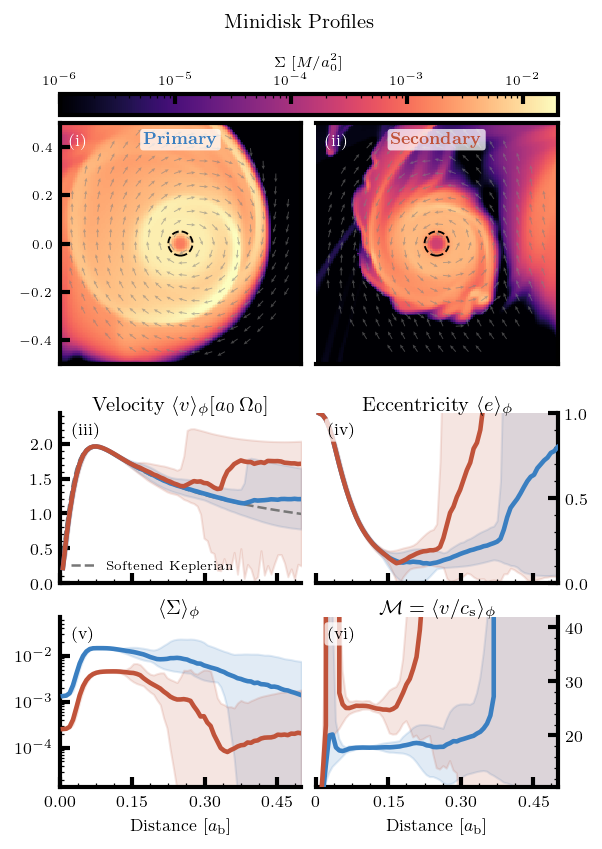

In [81]:
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle

vlim            = 1.1 * np.nanmax([np.nanmax(PrimaryMiniDisk['MaxV']),  np.nanmax(SecondaryMiniDisk['MaxV'])])
dlim            = 3.0 * np.nanmax([np.nanmax(PrimaryMiniDisk['MaxD']),  np.nanmax(SecondaryMiniDisk['MaxD'])])
PrimaryRadius   = RadialBins_md[1:] #/ SinkRadius[0]
SecondaryRadius = RadialBins_md[1:] #/ SinkRadius[1]
xlim            = max(PrimaryRadius[-1], SecondaryRadius[-1])

_c_primary   = '#3A7FC1'
_c_secondary = '#C0533A'
_c_ref       = '#777777'

_sig_vals = np.concatenate([Sigma[primary_radius < RMinidisk].ravel(), Sigma[secondary_radius < RMinidisk].ravel()])
_sig_vals = _sig_vals[_sig_vals > 0]
_norm     = LogNorm(vmin=1e-6, vmax=2e-2)
_mach_all = np.concatenate([PrimaryMiniDisk['MeanM'], SecondaryMiniDisk['MeanM']])
_mac_max  = np.nanpercentile(_mach_all, 90) * 1.3
_mac_min  = 0.0

def _quiver_field(pos_x, pos_y, vel_x, vel_y):
    from scipy.interpolate import RegularGridInterpolator
    _nq   = 20
    _qgrd = np.linspace(-RMinidisk, RMinidisk, _nq)
    _qX, _qY = np.meshgrid(_qgrd, _qgrd)
    rgi_u = RegularGridInterpolator((y, x), vel_x, method='linear', bounds_error=False, fill_value=np.nan)
    rgi_v = RegularGridInterpolator((y, x), vel_y, method='linear', bounds_error=False, fill_value=np.nan)
    pts   = np.column_stack([(_qY + pos_y).ravel(), (_qX + pos_x).ravel()])
    U = rgi_u(pts).reshape(_nq, _nq)
    V = rgi_v(pts).reshape(_nq, _nq)
    R   = np.sqrt(_qX**2 + _qY**2)
    spd = np.sqrt(U**2 + V**2)
    spd[spd == 0] = np.nan
    U = np.where(R < RMinidisk, U / spd, np.nan)
    V = np.where(R < RMinidisk, V / spd, np.nan)
    return _qX, _qY, U, V

_qX_p, _qY_p, _qU_p, _qV_p = _quiver_field(primary.position_x,   primary.position_y,   Vx, Vy)
_qX_s, _qY_s, _qU_s, _qV_s = _quiver_field(secondary.position_x, secondary.position_y, Vx, Vy)

fig = plt.figure(figsize=(0.8*text_width, 1.12 * text_width), dpi=150)

gs_top = fig.add_gridspec(1, 2, left=0.10, right=0.93, top=0.925, bottom=0.609, wspace=0.06)
gs_bot = fig.add_gridspec(2, 2, left=0.10, right=0.93, top=0.565, bottom=0.12, hspace=0.20, wspace=0.06)

ax_pm  = fig.add_subplot(gs_top[0, 0])
ax_sm  = fig.add_subplot(gs_top[0, 1])
ax_vel = fig.add_subplot(gs_bot[0, 0])
ax_ecc = fig.add_subplot(gs_bot[0, 1])
ax_den = fig.add_subplot(gs_bot[1, 0])
ax_mac = fig.add_subplot(gs_bot[1, 1])

# --- (i, ii) density maps ---
for ax, pos_x, pos_y, title, c, sr, lbl, qX, qY, qU, qV in [
        (ax_pm, primary.position_x,   primary.position_y,   r'$\textbf{Primary}$',   _c_primary,   SinkRadius[0], 'i',  _qX_p, _qY_p, _qU_p, _qV_p),
        (ax_sm, secondary.position_x, secondary.position_y, r'$\textbf{Secondary}$', _c_secondary, SinkRadius[1], 'ii', _qX_s, _qY_s, _qU_s, _qV_s)]:
    im = ax.pcolormesh(X - pos_x, Y - pos_y, Sigma, cmap='magma', norm=_norm, shading='auto', rasterized=True)
    ax.set_xlim([-RMinidisk, RMinidisk])
    ax.set_ylim([-RMinidisk, RMinidisk])
    ax.set_aspect('equal')
    ax.tick_params(which='both', direction='in', labelsize=6, bottom=False, labelbottom=False)
    ax.quiver(qX, qY, qU, qV, color='grey', alpha=0.55, scale=28, width=0.004, headwidth=3.5, headlength=4, headaxislength=3.5, zorder=4)
    ax.add_patch(Circle((0, 0), sr, fill=False, edgecolor='black', linewidth=0.9, linestyle='dashed', zorder=5))
    ax.text(0.50, 0.96, title, transform=ax.transAxes, fontsize=8, fontweight='bold', va='top', ha='center', color=c, zorder=6, bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.2'))
    ax.text(0.04, 0.96, f'({lbl})', transform=ax.transAxes, fontsize=8, fontweight='bold', va='top', color='white', zorder=7)

#ax_pm.set_ylabel(r'$\Delta y\;[a_\mathrm{b}]$', fontsize=7)
ax_sm.tick_params(left=False, labelleft=False)
ax_sm.spines['left'].set_visible(False)



cax = fig.add_axes([0.10, 0.92, 0.83, 0.025])
cb  = fig.colorbar(im, cax=cax, orientation='horizontal', location='top')
#cb = fig.colorbar(im, ax=[ax_pm, ax_sm], location='top', shrink=1.0, pad=0.02, aspect=25)
cb.set_label(r'$\Sigma\;[M/a_0^2]$', fontsize=7)
cb.ax.tick_params(labelsize=6)

# --- profile panel style ---
for ax in (ax_vel, ax_ecc, ax_den, ax_mac):
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(which='both', direction='in', top=False, right=False)
    ax.minorticks_on()

for ax in (ax_ecc, ax_mac):
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position('right')
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(True)
    ax.tick_params(which='both', direction='in', right=True, left=False)

for ax in (ax_vel, ax_ecc):
    ax.tick_params(labelbottom=False)

for ax in (ax_den, ax_mac):
    ax.set_xlabel(r'Distance $[a_\mathrm{b}]$')

# shared xticks on all four profile panels
for ax in (ax_vel, ax_ecc, ax_den, ax_mac):
    ax.set_xticks([0, 0.15, 0.3, 0.45])

for ax, lbl in zip((ax_vel, ax_ecc, ax_den, ax_mac), ('iii', 'iv', 'v', 'vi')):
    ax.text(0.05, 0.95, f'({lbl})', transform=ax.transAxes, fontsize=8, fontweight='bold', va='top', zorder=10, bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.2'))

ax_mac.set_xlim([0, xlim])

# --- (iii) Velocity ---
ax_vel.set_xlim([0, xlim])
ax_vel.set_ylim([0, vlim])
ax_vel.plot(PrimaryRadius,   PrimaryMiniDisk['MeanV'],   color=_c_primary,   linewidth=2.2, zorder=3)
ax_vel.plot(SecondaryRadius, SecondaryMiniDisk['MeanV'], color=_c_secondary, linewidth=2.2, zorder=3)
ax_vel.fill_between(PrimaryRadius,   PrimaryMiniDisk['MinV'],   PrimaryMiniDisk['MaxV'],   color=_c_primary,   alpha=0.15, zorder=1)
ax_vel.fill_between(SecondaryRadius, SecondaryMiniDisk['MinV'], SecondaryMiniDisk['MaxV'], color=_c_secondary, alpha=0.15, zorder=1)
ax_vel.plot(PrimaryRadius, [r * np.sqrt(primary.mass / ((r**2 + SoftRadius[0]**2)**1.5)) for r in RadialBins_md[1:]], color=_c_ref, linestyle='dashed', linewidth=1.2, label='Softened Keplerian', zorder=2)
ax_vel.legend(fontsize=6, frameon=False)
ax_vel.set_title(r'Velocity $\langle v \rangle_\phi[a_0\,\Omega_0]$', y=0.95)

# --- (iv) Eccentricity ---
ax_ecc.plot(PrimaryRadius,   PrimaryMiniDisk['MeanE'],   color=_c_primary,   linewidth=2.2, zorder=3)
ax_ecc.plot(SecondaryRadius, SecondaryMiniDisk['MeanE'], color=_c_secondary, linewidth=2.2, zorder=3)
ax_ecc.fill_between(PrimaryRadius,   PrimaryMiniDisk['MinE'],   PrimaryMiniDisk['MaxE'],   color=_c_primary,   alpha=0.15, zorder=1)
ax_ecc.fill_between(SecondaryRadius, SecondaryMiniDisk['MinE'], SecondaryMiniDisk['MaxE'], color=_c_secondary, alpha=0.15, zorder=1)
ax_ecc.set_xlim([0, xlim])
ax_ecc.set_ylim([0, 1])
ax_ecc.set_yticks([0.0, 0.5, 1.0])
ax_ecc.set_title(r'Eccentricity $\langle e\rangle_\phi$', y=0.95)

# --- (v) Surface density ---
ax_den.plot(PrimaryRadius,   PrimaryMiniDisk['MeanD'],   color=_c_primary,   linewidth=2.2, zorder=3)
ax_den.plot(SecondaryRadius, SecondaryMiniDisk['MeanD'], color=_c_secondary, linewidth=2.2, zorder=3)
ax_den.fill_between(PrimaryRadius,   PrimaryMiniDisk['MinD'],   PrimaryMiniDisk['MaxD'],   color=_c_primary,   alpha=0.15, zorder=1)
ax_den.fill_between(SecondaryRadius, SecondaryMiniDisk['MinD'], SecondaryMiniDisk['MaxD'], color=_c_secondary, alpha=0.15, zorder=1)
ax_den.set_xlim([0, xlim])
ax_den.set_ylim([dlim * 2e-4, dlim])
ax_den.set_yscale('log')
ax_den.set_title(r'$\langle\Sigma\rangle_\phi$', y=0.95)

# --- (vi) Mach ---
ax_mac.plot(PrimaryRadius,   PrimaryMiniDisk['MeanM'],   color=_c_primary,   linewidth=2.2, zorder=3)
ax_mac.plot(SecondaryRadius, SecondaryMiniDisk['MeanM'], color=_c_secondary, linewidth=2.2, zorder=3)
ax_mac.fill_between(PrimaryRadius,   PrimaryMiniDisk['MinM'],   PrimaryMiniDisk['MaxM'],   color=_c_primary,   alpha=0.15, zorder=1)
ax_mac.fill_between(SecondaryRadius, SecondaryMiniDisk['MinM'], SecondaryMiniDisk['MaxM'], color=_c_secondary, alpha=0.15, zorder=1)
ax_mac.set_xlim([0, xlim])
ax_mac.set_xticklabels(['0', '0.15', '0.30', '0.45'])
ax_mac.set_ylim([np.min(DiskStats['MeanM'])/2, np.min([np.max(DiskStats['MeanM']), 2*np.min(DiskStats['MeanM'])])])
ax_mac.set_title(r'$\mathcal{M} = \langle v/c_\mathrm{s}\rangle_\phi$', y=0.95)

fig.suptitle('Minidisk Profiles', y=1.04)
plt.savefig(f"Minidisks_OP.png", dpi=400, bbox_inches='tight')
